In [ ]:
import numpy as np
import pandas as pd
import yaml
from ultralytics import YOLO


def extract_obb_metrics_with_val_test(model_name, data_yaml):
    model_path = f"models/{model_name}"
    model = YOLO(model_path)

    val_metrics = model.val(data=data_yaml, split="val", plots=False)

    val_map50_95 = val_metrics.box.map
    val_map50 = val_metrics.box.map50
    val_map75 = val_metrics.box.map75
    val_maps_per_class = val_metrics.box.maps
    val_precision_per_class = val_metrics.box.p
    val_recall_per_class = val_metrics.box.r
    val_f1_per_class = val_metrics.box.f1

    test_metrics = model.val(data=data_yaml, split="test", plots=False)

    test_map50_95 = test_metrics.box.map
    test_map50 = test_metrics.box.map50
    test_map75 = test_metrics.box.map75
    test_maps_per_class = test_metrics.box.maps
    test_precision_per_class = test_metrics.box.p
    test_recall_per_class = test_metrics.box.r
    test_f1_per_class = test_metrics.box.f1

    with open(data_yaml, "r") as f:
        data_config = yaml.safe_load(f)
    class_names = data_config["names"]

    avg_val_map50_95 = np.mean(val_maps_per_class)
    avg_val_precision = np.mean(val_precision_per_class)
    avg_val_recall = np.mean(val_recall_per_class)
    avg_val_f1 = np.mean(val_f1_per_class)

    avg_test_map50_95 = np.mean(test_maps_per_class)
    avg_test_precision = np.mean(test_precision_per_class)
    avg_test_recall = np.mean(test_recall_per_class)
    avg_test_f1 = np.mean(test_f1_per_class)

    results = {
        "model_name": model_name,
        # Validierungs-Metriken (aggregiert)
        "val_map50": val_map50,
        "val_map50_95": val_map50_95,
        "val_map75": val_map75,
        "avg_val_map50_95": avg_val_map50_95,
        "avg_val_precision": avg_val_precision,
        "avg_val_recall": avg_val_recall,
        "avg_val_f1": avg_val_f1,
        # Validierungs-Metriken (pro Klasse)
        "val_maps_per_class": val_maps_per_class,
        "val_precision_per_class": val_precision_per_class,
        "val_recall_per_class": val_recall_per_class,
        "val_f1_per_class": val_f1_per_class,
        # Test-Metriken (aggregiert)
        "test_map50": test_map50,
        "test_map50_95": test_map50_95,
        "test_map75": test_map75,
        "avg_test_map50_95": avg_test_map50_95,
        "avg_test_precision": avg_test_precision,
        "avg_test_recall": avg_test_recall,
        "avg_test_f1": avg_test_f1,
        # Test-Metriken (pro Klasse)
        "test_maps_per_class": test_maps_per_class,
        "test_precision_per_class": test_precision_per_class,
        "test_recall_per_class": test_recall_per_class,
        "test_f1_per_class": test_f1_per_class,
        # Klassen-Namen
        "class_names": class_names,
    }

    return results

In [16]:
results

{'model_name': 'model-x.pt',
 'val_map50': np.float64(0.9880584161152411),
 'val_map50_95': np.float64(0.8846603150336071),
 'val_map75': np.float64(0.9839185900772545),
 'avg_val_map50_95': np.float64(0.8846603150336071),
 'avg_val_precision': np.float64(0.9811620710649273),
 'avg_val_recall': np.float64(0.9747240657604861),
 'avg_val_f1': np.float64(0.9775678003307006),
 'val_maps_per_class': array([    0.88981,     0.90609,     0.90519,     0.89905,     0.87026,     0.87366,     0.93638,     0.93317,     0.89991,     0.90327,     0.82091,     0.86922,     0.89183,     0.86381,     0.84614,     0.86147,     0.91884,     0.91909,      0.8632,     0.82192]),
 'val_precision_per_class': array([    0.99761,     0.98253,     0.99253,     0.99252,      0.9874,     0.99734,           1,      0.9877,     0.98148,     0.99959,     0.97603,           1,     0.96246,     0.95798,           1,     0.99047,     0.99641,     0.88742,     0.93971,     0.99406]),
 'val_recall_per_class': array([    

In [3]:
all_results = []
# Liste der Modellnamen
model_names = [
    "model-n.pt",  # nano
    "model-s.pt",  # small
    "model-m.pt",  # medium
    "model-l.pt",  # large
    "model-x.pt",  # extra-large
]
DATA_YAML = "data/data.yaml"
model_paths = [f"models/{name}" for name in model_names]

for model_name in model_names:
    print(f"Analysiere Modell: {model_name}...")
    results = extract_obb_metrics_with_val_test(model_name, DATA_YAML)
    all_results.append(results)
    print(f"Fertig mit {model_name}!\n")

Analysiere Modell: model-n.pt...
Ultralytics 8.4.92 🚀 Python-3.11.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 4500 Blackwell, 32125MiB)
YOLO26n-obb summary (fused): 132 layers, 2,450,307 parameters, 0 gradients, 5.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 126.4±28.0 MB/s, size: 326.0 KB)

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 17.7it/s 1.4s
                   all        384       2198      0.966      0.952      0.974      0.861
                    A1         35        161      0.963      0.932      0.986       0.86
                    A2         36        174      0.969      0.977      0.991      0.899
                    A3         33        148      0.986      0.969      0.992      0.899
                    A4         25        135      0.985      0.998      0.995      0.909
                    A5         40        164      0.974       0.92      0.939      0.808
                    A6        

In [17]:
all_results

[{'model_name': 'model-n.pt',
  'val_map50': np.float64(0.973990699164624),
  'val_map50_95': np.float64(0.8611242626556808),
  'val_map75': np.float64(0.9690643909130504),
  'avg_val_map50_95': np.float64(0.8611242626556811),
  'avg_val_precision': np.float64(0.9659269891715428),
  'avg_val_recall': np.float64(0.9519610150995776),
  'avg_val_f1': np.float64(0.9581731403988998),
  'val_maps_per_class': array([    0.85954,     0.89877,     0.89926,      0.9087,     0.80836,     0.86925,     0.93116,     0.92647,     0.88045,     0.91634,     0.86958,     0.85405,     0.82549,      0.8726,     0.65872,     0.83939,     0.89088,     0.89838,      0.8111,       0.804]),
  'val_precision_per_class': array([    0.96313,     0.96873,     0.98624,     0.98537,     0.97417,           1,     0.97953,     0.98287,     0.96455,     0.96648,     0.97657,           1,     0.86182,     0.97124,     0.96694,     0.94641,      0.9897,     0.98023,     0.85458,           1]),
  'val_recall_per_class': a

In [ ]:
comparison_df = pd.DataFrame(
    [
        {
            "Modell": res["model_name"],
            # Validierung
            "Val mAP@0.5": res["val_map50"],
            "Val mAP@0.5:0.95": res["val_map50_95"],
            "Val Avg. F1": res["avg_val_f1"],
            # Test
            "Test mAP@0.5": res["test_map50"],
            "Test mAP@0.5:0.95": res["test_map50_95"],
            "Test Avg. F1": res["avg_test_f1"],
            # Abweichung (Val - Test)
            "Δ mAP@0.5": res["val_map50"] - res["test_map50"],
            "Δ mAP@0.5:0.95": res["val_map50_95"] - res["test_map50_95"],
            "Δ Avg. F1": res["avg_val_f1"] - res["avg_test_f1"],
        }
        for res in all_results
    ]
)

# Sortieren nach Test-mAP@0.5:0.95
comparison_df = comparison_df.sort_values(by="Test mAP@0.5:0.95", ascending=False)
print(comparison_df)

       Modell  Val mAP@0.5  Val mAP@0.5:0.95  Val Avg. F1  Test mAP@0.5  \
3  model-l.pt     0.990633          0.888817     0.979695      0.980845   
4  model-x.pt     0.988058          0.884660     0.977568      0.980129   
2  model-m.pt     0.987276          0.885080     0.976850      0.977045   
1  model-s.pt     0.987452          0.881176     0.962278      0.978505   
0  model-n.pt     0.973991          0.861124     0.958173      0.971485   

   Test mAP@0.5:0.95  Test Avg. F1  Δ mAP@0.5  Δ mAP@0.5:0.95  Δ Avg. F1  
3           0.883571      0.968305   0.009788        0.005246   0.011390  
4           0.878837      0.969141   0.007929        0.005824   0.008427  
2           0.878011      0.968141   0.010232        0.007069   0.008709  
1           0.875866      0.957725   0.008946        0.005310   0.004553  
0           0.861435      0.944866   0.002506       -0.000311   0.013307  


In [ ]:
# Modelle mit großer Abweichung (Val >> Test) identifizieren
overfitting_threshold = 0.05  # Schwelle für Overfitting (z. B. 5% Abweichung)
overfitting_models = comparison_df[
    (comparison_df["Δ mAP@0.5"] > overfitting_threshold)
    | (comparison_df["Δ mAP@0.5:0.95"] > overfitting_threshold)
]

if not overfitting_models.empty:
    print("Modelle mit möglichem Overfitting:")
    print(overfitting_models[["Modell", "Δ mAP@0.5", "Δ mAP@0.5:0.95"]])
else:
    print("Kein Overfitting erkannt.")

Kein Overfitting erkannt.


In [ ]:
# DataFrame für Metriken pro Klasse und Modell (Val vs. Test)
class_comparison_list = []
for res in all_results:
    for i, class_name in enumerate(res["class_names"]):
        class_comparison_list.append(
            {
                "Modell": res["model_name"],
                "Klasse": class_name,
                "Val F1": res["val_f1_per_class"][i],
                "Test F1": res["test_f1_per_class"][i],
                "Δ F1": res["val_f1_per_class"][i] - res["test_f1_per_class"][i],
            }
        )

class_comparison_df = pd.DataFrame(class_comparison_list)

# Klassen mit großer Abweichung (Val vs. Test)
class_overfitting = class_comparison_df[class_comparison_df["Δ F1"] > 0.1]
if not class_overfitting.empty:
    print("Klassen mit möglichem Overfitting:")
    print(class_overfitting[["Modell", "Klasse", "Δ F1"]])
else:
    print("Keine Klassen mit Overfitting erkannt.")

Klassen mit möglichem Overfitting:
        Modell  Klasse      Δ F1
3   model-n.pt       3  0.134080
17  model-n.pt      17  0.101043


<Figure size 1200x600 with 0 Axes>

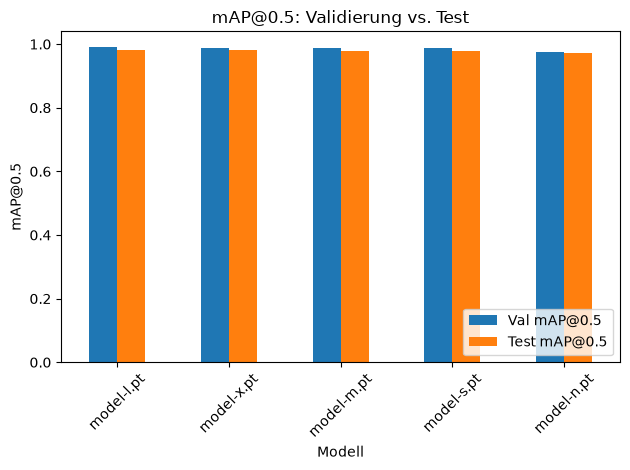

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
comparison_df.set_index("Modell")[["Val mAP@0.5", "Test mAP@0.5"]].plot(
    kind="bar", rot=45
)
plt.title("mAP@0.5: Validierung vs. Test")
plt.ylabel("mAP@0.5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

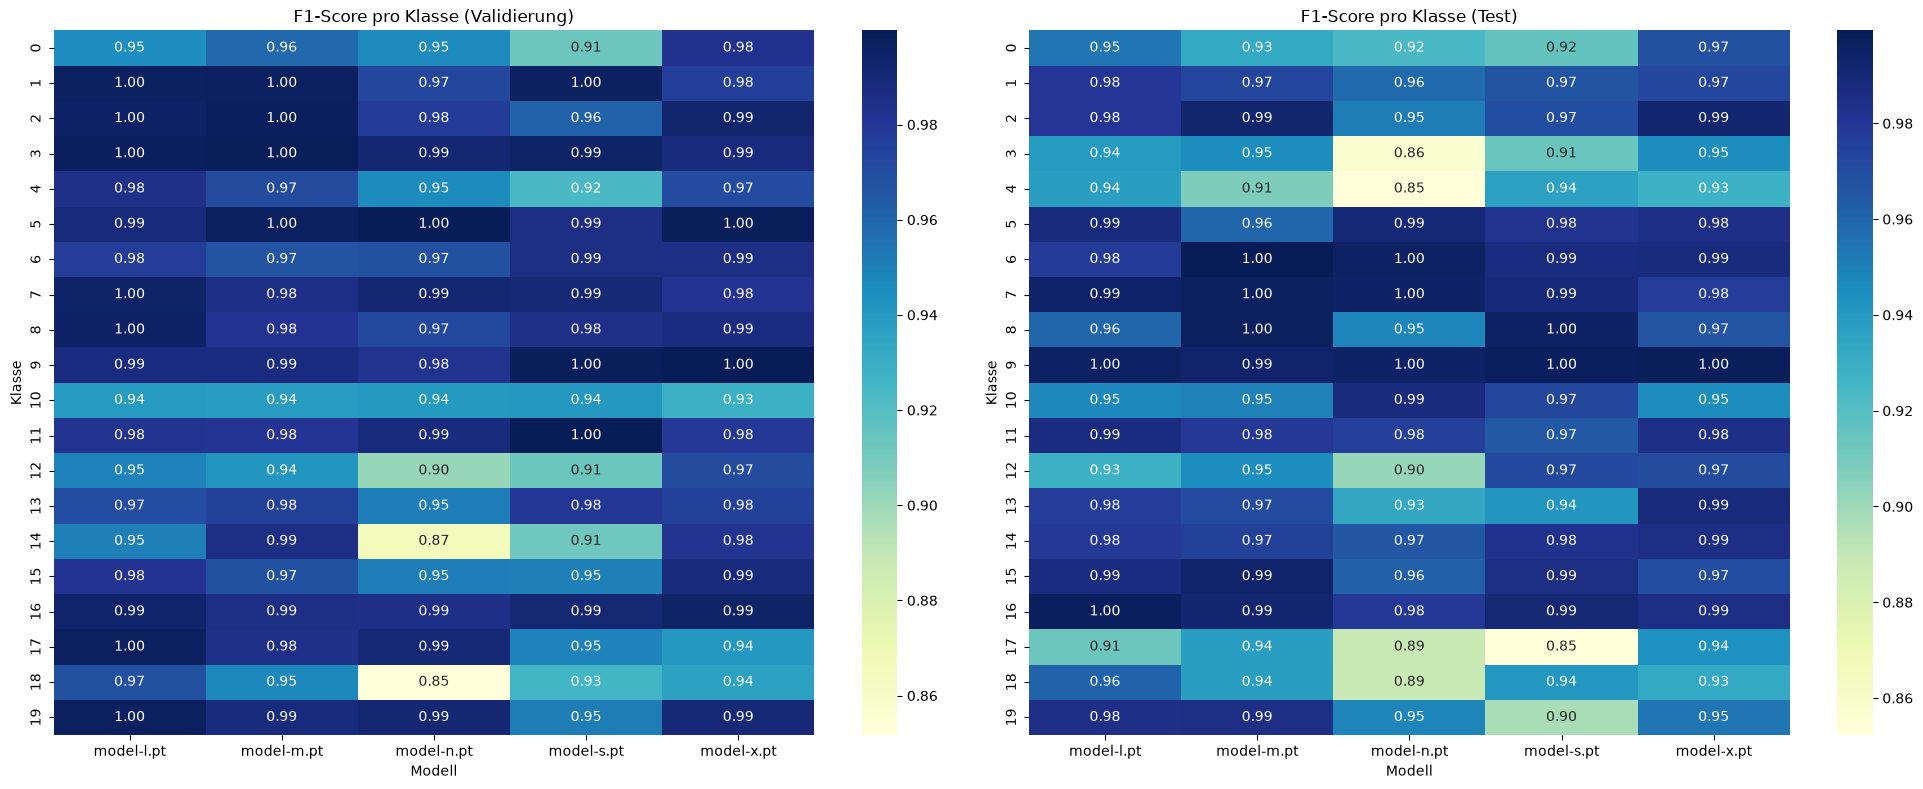

In [ ]:
# Pivot-Tabellen für Val und Test F1-Scores
f1_val_pivot = class_comparison_df.pivot(
    index="Klasse", columns="Modell", values="Val F1"
)
f1_test_pivot = class_comparison_df.pivot(
    index="Klasse", columns="Modell", values="Test F1"
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(f1_val_pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("F1-Score pro Klasse (Validierung)")
sns.heatmap(f1_test_pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("F1-Score pro Klasse (Test)")
plt.tight_layout()
plt.show()

In [ ]:
# Beste Modelle nach Test-mAP@0.5:0.95
best_models = comparison_df.nlargest(3, "Test mAP@0.5:0.95")

# Modelle mit Overfitting-Risiko
overfitting_models_list = comparison_df[
    (comparison_df["Δ mAP@0.5"] > 0.05) | (comparison_df["Δ mAP@0.5:0.95"] > 0.05)
]["Modell"].tolist()

# Klassen mit den größten Abweichungen (Val vs. Test)
worst_classes = class_comparison_df.groupby("Klasse")["Δ F1"].mean().nlargest(3)

zusammenfassung = f"""
---
### **Zusammenfassung: Validierung vs. Test für YOLOv26-OBB-Modelle**

**Beste Modelle nach Test-mAP@0.5:0.95:**
{best_models.to_markdown(index=False)}

**Modelle mit Overfitting-Risiko (Val >> Test):**
{", ".join(overfitting_models_list) if overfitting_models_list else "Keine"}

**Klassen mit den größten Abweichungen (Val vs. Test):**
{worst_classes.to_markdown()}

---
### **Empfehlungen:**
1. **Modellauswahl**:
   - **Beste Generalisierung**: **{best_models.iloc[0]["Modell"]}** (Test-mAP@0.5:0.95: {best_models.iloc[0]["Test mAP@0.5:0.95"]:.2f}).
   - **Overfitting-Check**: Modelle mit großer Abweichung (Val vs. Test) vermeiden (z. B. {", ".join(overfitting_models_list) if overfitting_models_list else "keine"}).

2. **Datensatz-Optimierung**:
     - **Klassen mit großen Abweichungen** (z. B. {", ".join(worst_classes.index.astype(str))}):
     - Mehr Test-Daten für diese Klassen sammeln.
     - Überprüfen, ob die Klassen im Val- und Test-Set **repräsentativ** sind.

3. **Modell-Optimierung**:
   - **Regularisierung**: Falls Overfitting auftritt, **Dropout** oder **Weight Decay** erhöhen.
   - **Frühes Stoppen**: Training stoppen, wenn Val-mAP nicht mehr steigt.
   - **Datenaugmentierung**: Besonders für Klassen mit großen Abweichungen.
"""
print(zusammenfassung)


---
### **Zusammenfassung: Validierung vs. Test für YOLOv26-OBB-Modelle**

**Beste Modelle nach Test-mAP@0.5:0.95:**
| Modell     |   Val mAP@0.5 |   Val mAP@0.5:0.95 |   Val Avg. F1 |   Test mAP@0.5 |   Test mAP@0.5:0.95 |   Test Avg. F1 |   Δ mAP@0.5 |   Δ mAP@0.5:0.95 |   Δ Avg. F1 |
|:-----------|--------------:|-------------------:|--------------:|---------------:|--------------------:|---------------:|------------:|-----------------:|------------:|
| model-l.pt |      0.990633 |           0.888817 |      0.979695 |       0.980845 |            0.883571 |       0.968305 |  0.00978832 |       0.00524649 |  0.0113903  |
| model-x.pt |      0.988058 |           0.88466  |      0.977568 |       0.980129 |            0.878837 |       0.969141 |  0.0079294  |       0.00582368 |  0.00842679 |
| model-m.pt |      0.987276 |           0.88508  |      0.97685  |       0.977045 |            0.878011 |       0.968141 |  0.0102316  |       0.00706899 |  0.008709   |

**Modelle mit Overfitting-

### **Zusammenfassung: Validierung vs. Test für YOLOv26-OBB-Modelle**

**Beste Modelle nach Test-mAP@0.5:0.95:**
| Modell     |   Val mAP@0.5 |   Val mAP@0.5:0.95 |   Val Avg. F1 |   Test mAP@0.5 |   Test mAP@0.5:0.95 |   Test Avg. F1 |   Δ mAP@0.5 |   Δ mAP@0.5:0.95 |   Δ Avg. F1 |
|:-----------|--------------:|-------------------:|--------------:|---------------:|--------------------:|---------------:|------------:|-----------------:|------------:|
| model-l.pt |      0.990633 |           0.888817 |      0.979695 |       0.980845 |            0.883571 |       0.968305 |  0.00978832 |       0.00524649 |  0.0113903  |
| model-x.pt |      0.988058 |           0.88466  |      0.977568 |       0.980129 |            0.878837 |       0.969141 |  0.0079294  |       0.00582368 |  0.00842679 |
| model-m.pt |      0.987276 |           0.88508  |      0.97685  |       0.977045 |            0.878011 |       0.968141 |  0.0102316  |       0.00706899 |  0.008709   |

**Modelle mit Overfitting-Risiko (Val >> Test):**
Keine

**Klassen mit den größten Abweichungen (Val vs. Test):**
|   Klasse |      Δ F1 |
|---------:|----------:|
|        3 | 0.0736587 |
|       17 | 0.0651509 |
|        4 | 0.046615  |

---
### **Empfehlungen:**
1. **Modellauswahl**:
   - **Beste Generalisierung**: **model-l.pt** (Test-mAP@0.5:0.95: 0.88).
   - **Overfitting-Check**: Modelle mit großer Abweichung (Val vs. Test) vermeiden (z. B. keine).

2. **Datensatz-Optimierung**:
     - **Klassen mit großen Abweichungen** (z. B. 3, 17, 4):
     - Mehr Test-Daten für diese Klassen sammeln.
     - Überprüfen, ob die Klassen im Val- und Test-Set **repräsentativ** sind.

3. **Modell-Optimierung**:
   - **Regularisierung**: Falls Overfitting auftritt, **Dropout** oder **Weight Decay** erhöhen.
   - **Frühes Stoppen**: Training stoppen, wenn Val-mAP nicht mehr steigt.
   - **Datenaugmentierung**: Besonders für Klassen mit großen Abweichungen.


In [21]:
comparison_df.to_csv("comparison.csv", index=False)

In [ ]:
import os

import pandas as pd

model_names = ["model-n.pt", "model-s.pt", "model-m.pt", "model-l.pt", "model-x.pt"]
model_paths = [f"models/{n}" for n in model_names]
DATA_YAML = "data/data.yaml"

general_rows = []
image_rows = []


def to_scalar(x):
    try:
        return float(x)
    except Exception:
        return x


for model_path in model_paths:
    print(f"Analysiere Modell: {os.path.basename(model_path)}...")
    model = YOLO(model_path)

    metrics = model.val(data=DATA_YAML, split="test")
    general_rows.append(
        {
            "model": os.path.basename(model_path),
            "mAP50": to_scalar(metrics.box.map50),
            "mAP50_95": to_scalar(metrics.box.map),
            "mAP75": to_scalar(getattr(metrics.box, "map75", None)),
            # (optional) number of classes / etc. if available
            "n_classes": to_scalar(getattr(metrics, "nc", None)),
        }
    )

    im = metrics.box.image_metrics

    if isinstance(im, pd.DataFrame):
        df_im = im.copy()
    else:
        try:
            df_im = pd.DataFrame(im)
        except Exception:
            # try dict -> rows
            df_im = pd.DataFrame([im])

    if len(df_im) > 0:
        df_im.insert(0, "model", os.path.basename(model_path))
        image_rows.append(df_im)

general_df = pd.DataFrame(general_rows)

image_df = pd.concat(image_rows, ignore_index=True) if image_rows else pd.DataFrame()

general_df.to_csv("general_metrics.csv", index=False)
image_df.to_csv("image_metrics.csv", index=False)


Analysiere Modell: model-n.pt...
Ultralytics 8.4.92 🚀 Python-3.11.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 4500 Blackwell, 32125MiB)
YOLO26n-obb summary (fused): 132 layers, 2,450,307 parameters, 0 gradients, 5.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.1 ms, read: 24.1±16.8 MB/s, size: 236.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.9it/s 3.2s
                   all        385       2379      0.951       0.94      0.971      0.861
                    A1         41        201      0.947        0.9      0.969      0.837
                    A2         40        215      0.969      0.949      0.987      0.878
                    A3         42        165      0.951      0.952      0.983       0.88
                    A4         12         53      0.89

In [43]:
image_df

,model,675.jpg,530.jpg,3841.jpg,308.jpg,444.jpg,706.jpg,55.jpg,488.jpg,333.jpg,...,44.jpg,58.jpg,607.jpg,248.jpg,50.jpg,42.jpg,43.jpg,33.jpg,276.jpg,2.jpg
0,model-n.pt,0.478873,0.666667,1.0,1.000000,1.0,0.727273,1.0,0.666667,0.800000,...,0.800000,1.000000,0.857143,0.800000,0.750000,0.487179,0.769231,1.0,0.764706,1.000000
1,model-n.pt,0.944444,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
2,model-n.pt,0.635514,0.800000,1.0,1.000000,1.0,0.842105,1.0,0.800000,0.888889,...,0.888889,1.000000,0.923077,0.888889,0.857143,0.655172,0.869565,1.0,0.866667,1.000000
3,model-n.pt,34.000000,10.000000,7.0,11.000000,6.0,8.000000,3.0,6.000000,4.000000,...,8.000000,2.000000,6.000000,12.000000,3.000000,19.000000,10.000000,2.0,13.000000,4.000000
4,model-n.pt,37.000000,5.000000,0.0,0.000000,0.0,3.000000,0.0,3.000000,1.000000,...,2.000000,0.000000,1.000000,3.000000,1.000000,20.000000,3.000000,0.0,4.000000,0.000000
5,model-n.pt,2.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
6,model-s.pt,0.576271,0.769231,1.0,1.000000,1.0,0.888889,1.0,0.600000,0.571429,...,1.000000,1.000000,0.600000,0.857143,1.000000,0.863636,0.909091,1.0,1.000000,1.000000
7,model-s.pt,0.944444,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
8,model-s.pt,0.715789,0.869565,1.0,1.000000,1.0,0.941176,1.0,0.750000,0.727273,...,1.000000,1.000000,0.750000,0.923077,1.000000,0.926829,0.952381,1.0,1.000000,1.000000
9,model-s.pt,34.000000,10.000000,7.0,11.000000,6.0,8.000000,3.0,6.000000,4.000000,...,8.000000,2.000000,6.000000,12.000000,3.000000,19.000000,10.000000,2.0,13.000000,4.000000


In [47]:
for row in image_rows:
    print(row)

                model    675.jpg    530.jpg  3841.jpg  308.jpg  444.jpg  \
precision  model-n.pt   0.478873   0.666667       1.0      1.0      1.0   
recall     model-n.pt   0.944444   1.000000       1.0      1.0      1.0   
f1         model-n.pt   0.635514   0.800000       1.0      1.0      1.0   
tp         model-n.pt  34.000000  10.000000       7.0     11.0      6.0   
fp         model-n.pt  37.000000   5.000000       0.0      0.0      0.0   
fn         model-n.pt   2.000000   0.000000       0.0      0.0      0.0   

            706.jpg  55.jpg   488.jpg   333.jpg  ...    44.jpg  58.jpg  \
precision  0.727273     1.0  0.666667  0.800000  ...  0.800000     1.0   
recall     1.000000     1.0  1.000000  1.000000  ...  1.000000     1.0   
f1         0.842105     1.0  0.800000  0.888889  ...  0.888889     1.0   
tp         8.000000     3.0  6.000000  4.000000  ...  8.000000     2.0   
fp         3.000000     0.0  3.000000  1.000000  ...  2.000000     0.0   
fn         0.000000     0.0  0

In [ ]:
for i, row in enumerate(image_rows):
    row.to_csv(
        f"metrics_{i}.csv", index=True
    )  # index=True keeps precision/recall/f1/tp/fp/fn

In [ ]:
import pandas as pd

df = pd.read_csv("metrics_3.csv", index_col=0)

for r in ["fp", "fn"]:
    df.loc[r] = pd.to_numeric(df.loc[r], errors="coerce")

fp_list = [c for c in df.columns if df.loc["fp", c] > 0]
fn_list = [c for c in df.columns if df.loc["fn", c] > 0]

print("False positives (FP>0):", fp_list)
print("False negatives (FN>0):", fn_list)


False positives (FP>0): ['675.jpg', '530.jpg', '488.jpg', '333.jpg', '57.jpg', '396.jpg', '635.jpg', '111.jpg', '660.jpg', '631.jpg', '549.jpg', '682.jpg', '561.jpg', '3603.jpg', '3341.jpg', '3231.jpg', '3221.jpg', '3210.jpg', '3805.jpg', '3778.jpg', '376.jpg', '3759.jpg', '3727.jpg', '3708.jpg', '3366.jpg', '3356.jpg', '3018.jpg', '2968.jpg', '2944.jpg', '2867.jpg', '2845.jpg', '2771.jpg', '3093.jpg', '3401.jpg', '3386.jpg', '3132.jpg', '3101.jpg', '3099.jpg', '3081.jpg', '3077.jpg', '3041.jpg', '69.jpg', '1125.jpg', '1120.jpg', '1202.jpg', '1126.jpg', '826.jpg', '3807.jpg', '1104.jpg', '1107.jpg', '1117.jpg', '846.jpg', '820.jpg', '801.jpg', '509.jpg', '77.jpg', '73.jpg', '1170.jpg', '1169.jpg', '1148.jpg', '1437.jpg', '3698.jpg', '3695.jpg', '366.jpg', '3655.jpg', '438.jpg', '1428.jpg', '1422.jpg', '1419.jpg', '3544.jpg', '3541.jpg', '472.jpg', '1314.jpg', '1301.jpg', '1299.jpg', '1293.jpg', '1378.jpg', '462.jpg', '1624.jpg', '1732.jpg', '1724.jpg', '1699.jpg', '1694.jpg', '1680.jpg

In [ ]:
model = YOLO("models/model-l.pt")
results = model.predict(source="data/test/images", save=True, save_txt=True)


image 1/385 /workspace/data/test/images/1000.jpg: 640x640 2 A2s, 1 A3, 29.3ms
image 2/385 /workspace/data/test/images/1009.jpg: 640x640 6 A17s, 29.3ms
image 3/385 /workspace/data/test/images/1016.jpg: 640x640 3 A1s, 1 A19, 28.9ms
image 4/385 /workspace/data/test/images/1018.jpg: 640x640 4 A1s, 28.8ms
image 5/385 /workspace/data/test/images/102.jpg: 640x640 7 A2s, 1 A3, 28.8ms
image 6/385 /workspace/data/test/images/1022.jpg: 640x640 7 A13s, 29.0ms
image 7/385 /workspace/data/test/images/1035.jpg: 640x640 3 A9s, 23.0ms
image 8/385 /workspace/data/test/images/1042.jpg: 640x640 4 A1s, 5 A19s, 28.8ms
image 9/385 /workspace/data/test/images/1048.jpg: 640x640 4 A14s, 28.9ms
image 10/385 /workspace/data/test/images/105.jpg: 640x640 1 A7, 19.8ms
image 11/385 /workspace/data/test/images/1053.jpg: 640x640 5 A15s, 28.8ms
image 12/385 /workspace/data/test/images/1065.jpg: 640x640 1 A2, 1 A9, 2 A11s, 2 A14s, 29.0ms
image 13/385 /workspace/data/test/images/1089.jpg: 640x640 4 A2s, 1 A3, 28.4ms
imag

In [ ]:
import os

import cv2
import pandas as pd

metrics_csv = "metrics_3.csv"
gt_labels_dir = "data/test/labels"  # YOLO txt ground truth
img_dir = "data/test/images"  # test images
pred_labels_dir = "runs/obb/predict/labels"  # predicted txts
out_dir = "fp_fn_exports"
os.makedirs(out_dir, exist_ok=True)

df = pd.read_csv(metrics_csv, index_col=0)
for r in ["fp", "fn"]:
    if r in df.index:
        df.loc[r] = pd.to_numeric(df.loc[r], errors="coerce")

fp_files = [
    c
    for c in df.columns
    if ("fp" in df.index and pd.notna(df.loc["fp", c]) and df.loc["fp", c] > 0)
]
fn_files = [
    c
    for c in df.columns
    if ("fn" in df.index and pd.notna(df.loc["fn", c]) and df.loc["fn", c] > 0)
]


def load_obb_txt(txt_path):
    """
    Expects YOLO OBB format: class x1 y1 x2 y2 x3 y3 x4 y4 (all normalized)
    Returns list of (cls, pts[4,2])
    """
    out = []
    if not os.path.exists(txt_path):
        return out
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 9:
                continue
            cls = int(float(parts[0]))
            coords = list(map(float, parts[1:9]))
            pts = [(coords[i], coords[i + 1]) for i in range(0, 8, 2)]
            out.append((cls, pts))
    return out


def find_img_path(base):
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        p = os.path.join(img_dir, base + ext)
        if os.path.exists(p):
            return p
    return None


def draw_polys(img, preds, color):
    h, w = img.shape[:2]
    for cls, pts in preds:
        xy = [
            (int(x * nw), int(y * nh)) for (x, y), nw, nh in zip(pts, [w] * 4, [h] * 4)
        ]
        poly = np.array(xy, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [poly], True, color, 2)
        # label
        x0, y0 = xy[0]
        cv2.putText(
            img, str(cls), (x0, y0 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
        )


MAX_PER_TYPE = 20


def export_list(file_list, tag):
    for name in file_list[:MAX_PER_TYPE]:
        base = os.path.splitext(name)[0]
        img_path = find_img_path(base)
        if img_path is None:
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        gt_path = os.path.join(gt_labels_dir, base + ".txt")
        pred_path = os.path.join(pred_labels_dir, base + ".txt")

        gt = load_obb_txt(gt_path)
        pr = load_obb_txt(pred_path)

        draw_polys(img, gt, (0, 255, 0))
        draw_polys(img, pr, (0, 0, 255))

        out_path = os.path.join(out_dir, f"{tag}_{name}")
        cv2.imwrite(out_path, img)


export_list(fp_files, "FP")
export_list(fn_files, "FN")

print("Done. Wrote exports to:", out_dir)
print("FP count:", len(fp_files), "FN count:", len(fn_files))


Done. Wrote exports to: fp_fn_exports
FP count: 157 FN count: 10
